# Magnitude Schechter

In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Magnitude sampling

In [9]:
def absMag2lum(M, M_star):
    """Return the luminosity frome the absolute magnitude M and a reference  absolute magnitude M_sar."""
    return 10**(0.4 * (M_star - M))


def proba_schechter_mag(M, M_star, alpha):
    """Compute the relative probability of a magnitude M.
    M_star is the caracteristic magnitude of Schechter's luminosity function."""
    L_ratio = absMag2lum(M, M_star) #Conversion magnitude -> relative luminosity L/L*
    return (L_ratio**alpha) * np.exp(-L_ratio)


def generate_schechter_magnitudes(N, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1):
    """Generate N randomized absolute magnitudes, by using a reject test and Schechter's law."""
    magnitudes = []
    while len(magnitudes) < N:
        M_test = np.random.uniform(M_min, M_max)
        p_test = np.random.uniform(0, 1) #Probability for rejet test
        if p_test < proba_schechter_mag(M_test, M_star, alpha): magnitudes.append(M_test)         
    return np.array(magnitudes)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def generate_magLum(N, z_min=0.01, z_max=3.0, M_min=-23, M_max=-15, M_star=-20.44, alpha=-1.1, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    M = generate_schechter_magnitudes(N, M_min, M_max, M_star, alpha) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    L = absMag2lum(M, M_sun) #luminosities
    return z, m, M, L, dL_mpc

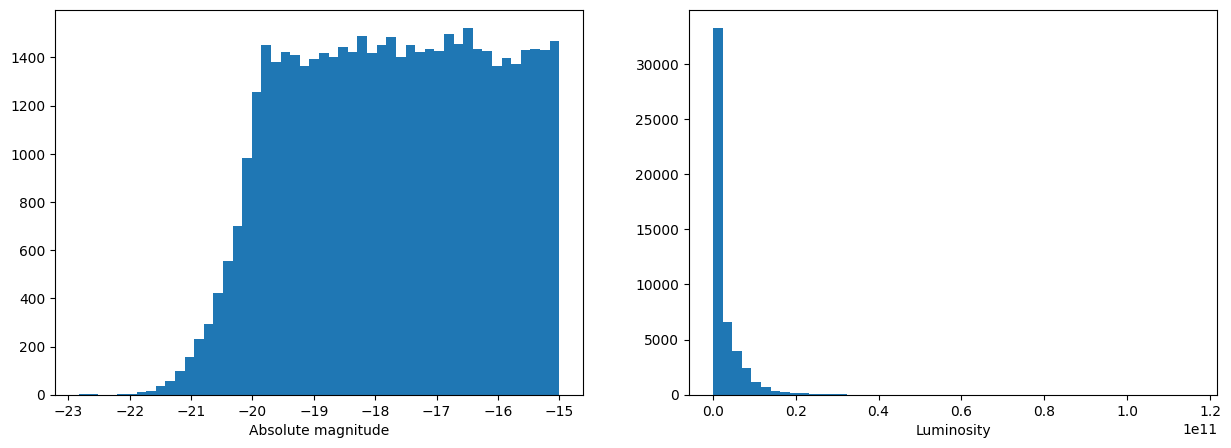

In [4]:
z, m, M, L, dL_mpc = generate_magLum(npix)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]));

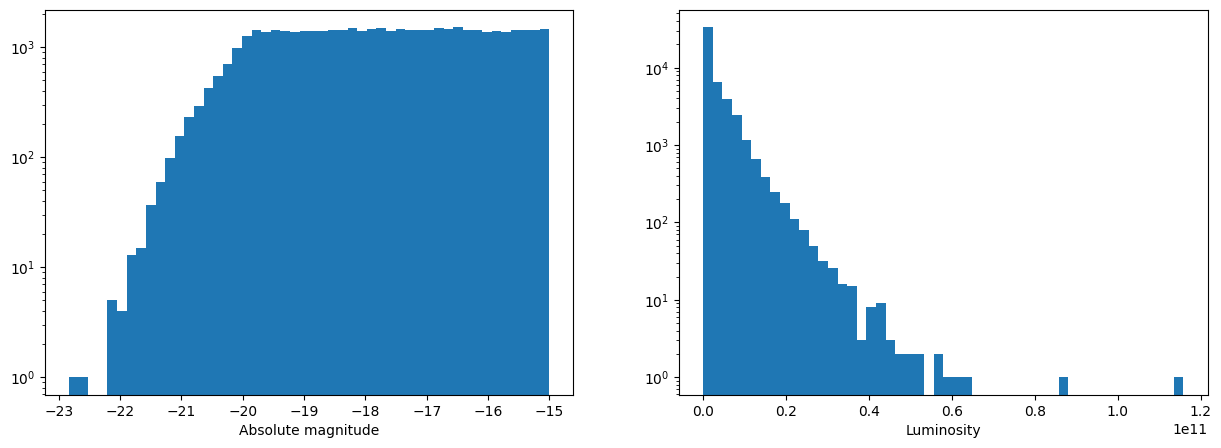

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_yscale('log');

## Luminosity sampling

### Linear space:

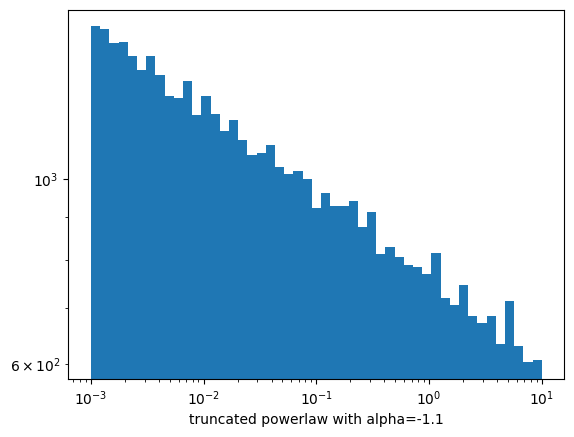

In [3]:
def sample_truncated_power_law(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ x^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = xmin ** exponent
    xmax_exp = xmax ** exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) ** (1 / exponent)

    return samples


x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=bins);
plt.yscale('log');
plt.xscale('log');

#### Testing power law:

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.537e+04 (χ²/ndof = 736.9)│              Nfcn = 35               │
│ EDM = 1.81e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ aplha │  -1.1503  │  0.0014   │  -0.0014   │   0.0014   │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │         aplha         │
├──────────┼───────────┬───────────┤
│  Error   │  -0.0014  │  0.0014   │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───────┬──────────┐
│       │    aplha │
├───────┼──────────┤
│ aplha │ 1.89e-06 │
└───────┴──────────┘

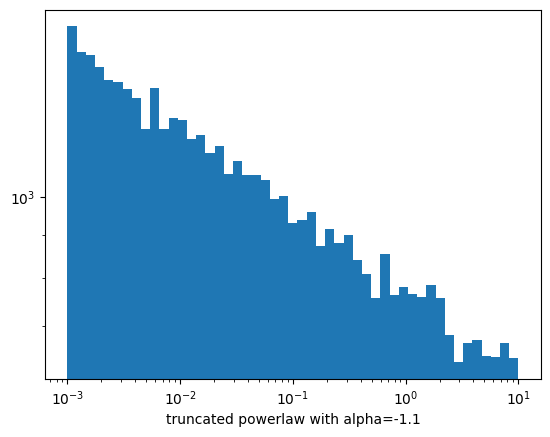

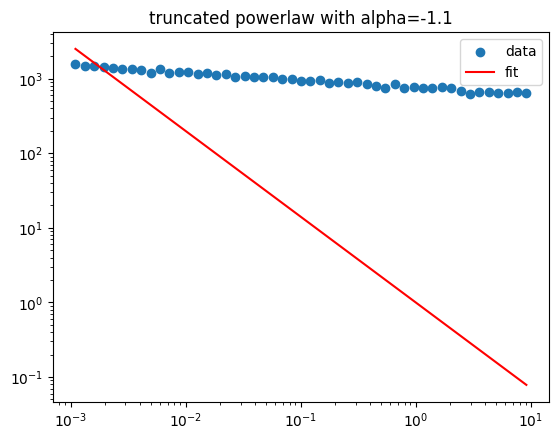

In [122]:
x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
binshist = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
var, bins = get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=binshist)
plt.yscale('log')
plt.xscale('log')
#plt.xscale('log');

model = lambda x, a : x**a
m = fit_minuit(bins, var, np.sqrt(var), model, (-1,), ("aplha",),
              title="truncated powerlaw with alpha=-1.1", xlabel="")
plt.yscale('log')
plt.xscale('log')
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.428e+08 (χ²/ndof = 15474468.7)│              Nfcn = 50               │
│ EDM = 1.27e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ aplha │ -6.740358 │ 0.000025  │ -0.000025  │  0.000025  │         │    0    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │         aplha         │
├──────────┼───────────┬───────────┤
│  Error   │ -0.025e-3 │ 0.025e-3  │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───────┬──────────┐
│       │    aplha │
├───────┼──────────┤
│ aplha │ 6.43e-10 │
└───────┴──────────┘

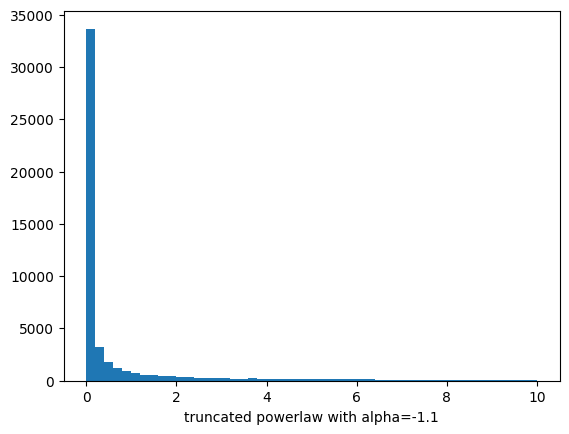

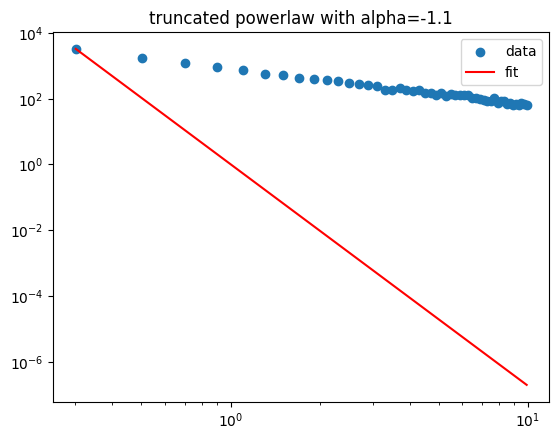

In [113]:
x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
var, bins = get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=50);
var, bins = var[1:], bins[1:]
#plt.xscale('log');

model = lambda x, a : x**a
m = fit_minuit(bins, var, 0.1, model, (-1,), ("aplha",),
              title="truncated powerlaw with alpha=-1.1", xlabel="", bounds=(-np.inf,0))
plt.yscale('log')
plt.xscale('log')
m

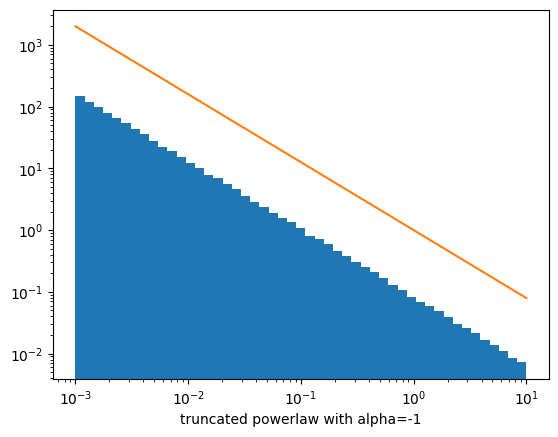

In [143]:
x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
binshist = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1', bins=binshist, density=True);
#plt.xscale('log');

x_test = np.linspace(1e-3, 10, 1000)
y = x_test**(-1.1)
plt.plot(x_test,y)
plt.yscale('log');
plt.xscale('log');

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.976e+09 (χ²/ndof = 81144912.4)│              Nfcn = 52               │
│ EDM = 4.09e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ aplha │-1.9333144 │ 0.0000029 │ -0.0000029 │ 0.0000029  │         │         │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┐
│          │         aplha         │
├──────────┼───────────┬───────────┤
│  Error   │  -2.9e-6  │  2.9e-6   │
│  Valid   │   True    │   True    │
│ At Limit │   False   │   False   │
│ Max FCN  │   False   │   False   │
│ New Min  │   False   │   False   │
└──────────┴───────────┴───────────┘
┌───────┬──────────┐
│       │    aplha │
├───────┼──────────┤
│ aplha │ 8.53e-12 │
└───────┴──────────┘

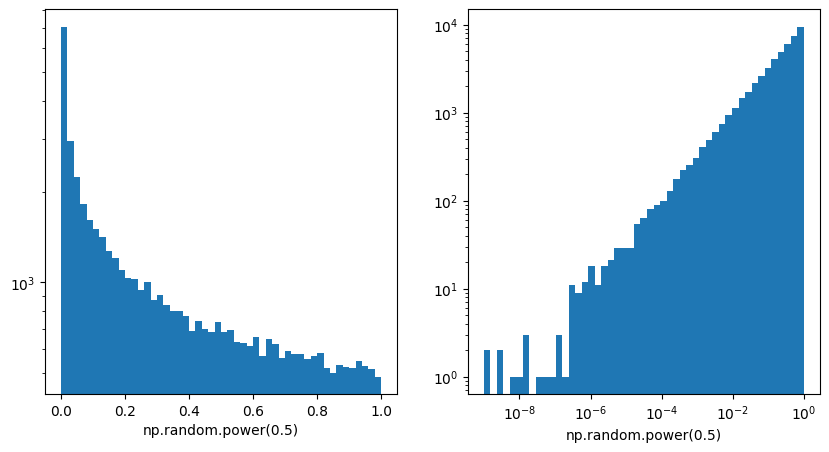

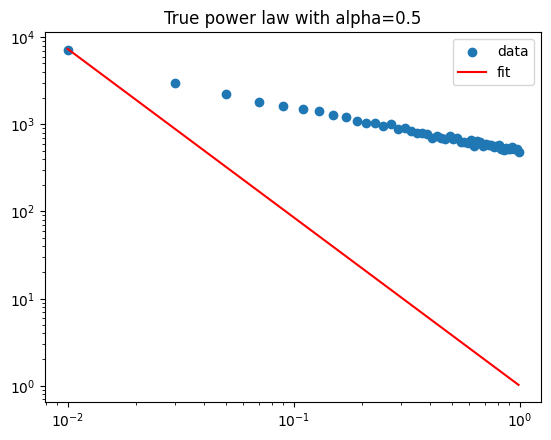

In [30]:
x = np.random.power(0.5, npix)
binshist = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
var, bins = get_hist(x, xlabel='np.random.power(0.5)', bins=50, log=True, figax=(fig, ax[0]))
get_hist(x, xlabel='np.random.power(0.5)', bins=binshist, log=True, figax=(fig, ax[1]))
ax[1].set_xscale('log');


model = lambda x, a : x**a
m = fit_minuit(bins, var, 0.1, model, (1,), ("aplha",), #bounds=(0.5, 1),
              title="True power law with alpha=0.5", xlabel="")
plt.yscale('log')
plt.xscale('log')
m

#### Schechter:

In [31]:
def proba_schechter_lum(L, L_star, alpha, phi_star=1):
        return phi_star * np.power(L/L_star, alpha) * np.exp(-L/L_star)


def generate_schechter_lum(n_samples, L_star, alpha, L_min, L_max, phi_star=1, get_proba=False):
    """Generate N randomized luminosities, by using a reject test and Schechter's law."""
    samples = []
    proba = []
    reject = 0 #to count the number of rejects
    f_max = proba_schechter_lum(L_min, L_star, alpha, phi_star) # The maximum value of the function on [L_min, L_max] is often at L_min if alpha < -1
    while len(samples) < n_samples:
        L_cand = sample_truncated_power_law(alpha, L_min, L_max)
        L_test =  L_cand**alpha #g(L_cand)
        p_test = np.random.uniform(0, L_test)
        
        if p_test < L_test/proba_schechter_lum(L_cand, L_star, alpha, phi_star):
            samples.append(L_cand)
            proba.append(p_test)
        else: reject += 1
    print('Number of rejects =', reject)
    if get_proba: return np.array(samples), np.array(proba)
    else: return np.array(samples)


def lum2absMag(L, M_sun=4.83, L_sun=1):
    return M_sun - 2.5*np.log10(L/L_sun)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def generate_lumMag(N, L_min=1e7, L_max=1e11,  L_star=1e10, alpha=-1.1, z_min=0.01, z_max=3.0, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    L_sun = kwargs.get('L_sun', 1) #Luminosity of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    L = generate_schechter_lum(N, L_star, alpha, L_min, L_max)  #luminosities
    M = lum2absMag(L, M_sun, L_sun) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    return z, m, M, L, dL_mpc

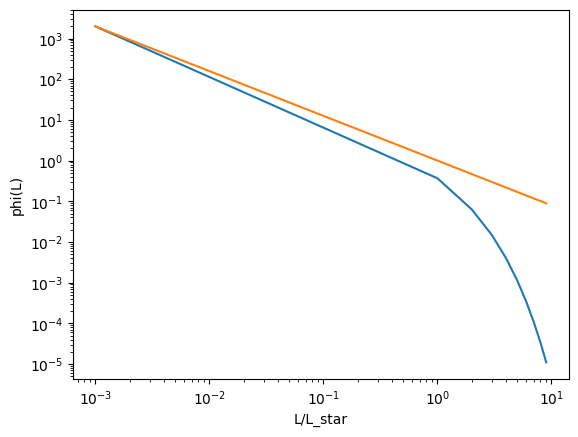

In [32]:
L_test = np.arange(1, 10000, 1000)
#L_test = np.logspace(1, 10000, 1000)
phi_test = proba_schechter_lum(L_test, 1000, -1.1)
L_ratio = L_test/1000
pow = L_ratio**(-1.1)
plt.plot(L_ratio, phi_test, label='phi')
plt.plot(L_ratio, pow, label='Lration**alpha')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('L/L_star')
plt.ylabel('phi(L)');

Number of rejects = 125700


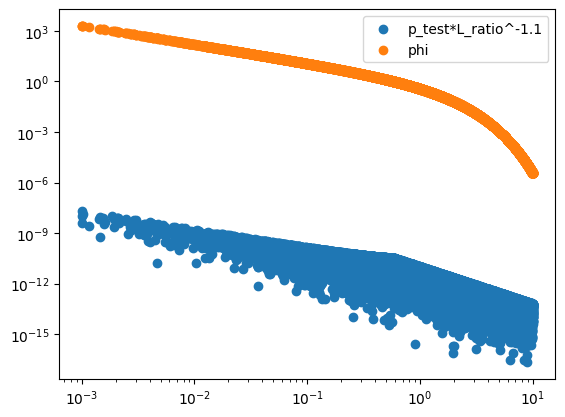

In [41]:
L, p = generate_schechter_lum(npix, L_star=1e10, alpha=-1.1, L_min=1e7, L_max=1e11, phi_star=1, get_proba=True)
phi = proba_schechter_lum(L, 1e10, -1.1)
y = p*np.power(L/1e10, -1.1)
plt.scatter(L/1e10, y, label='p_test*L_ratio^-1.1');
plt.scatter(L/1e10, phi, label='phi')
plt.xscale('log')
plt.yscale('log')
plt.legend();

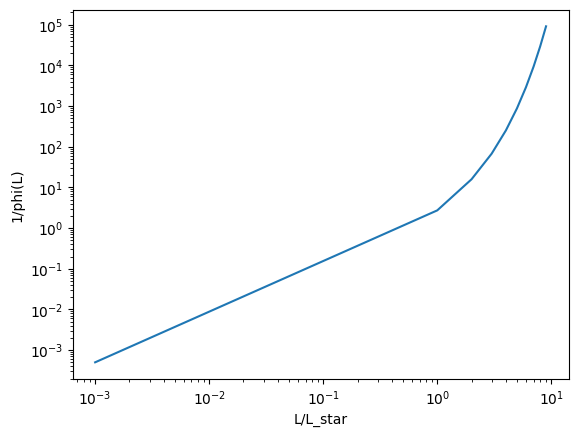

In [6]:
L_test = np.arange(1, 10000, 1000)
phi_test = proba_schechter_lum(L_test, 1000, -1.1)
L_ratio = L_test/1000
plt.plot(L_ratio, 1/phi_test)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('L/L_star')
plt.ylabel('1/phi(L)');

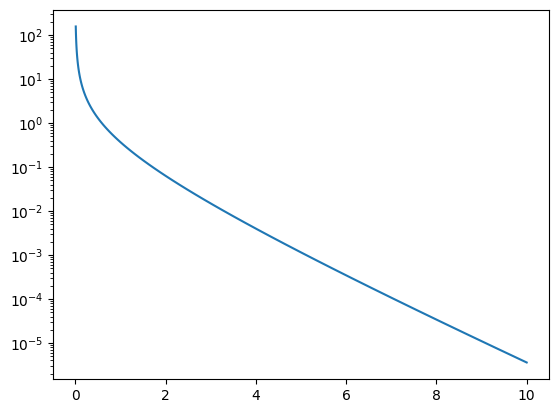

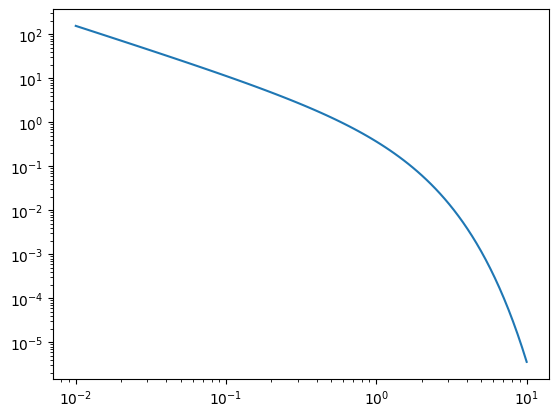

In [7]:
x=np.logspace(-2,1,100)
y=np.power(x,-1.1)*np.exp(-x)
plt.semilogy(x,y)
plt.figure()
plt.loglog(x,y);

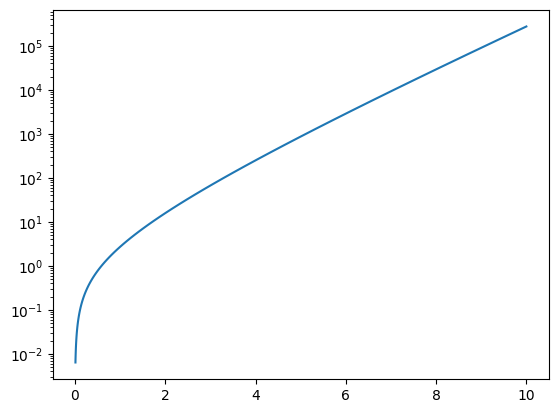

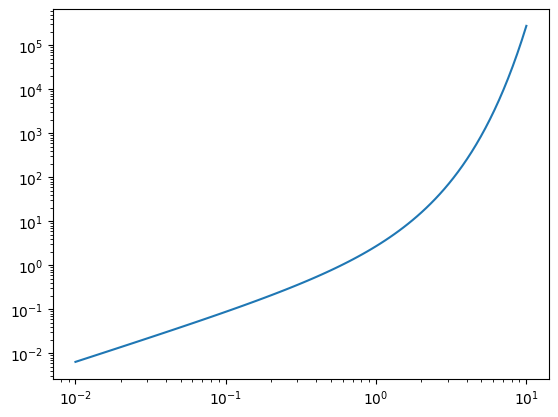

In [8]:
x=np.logspace(-2,1,100)
y=np.power(x,-1.1)*np.exp(-x)
plt.semilogy(x, 1/y)
plt.figure()
plt.loglog(x,1/y);

Number of rejects = 124540


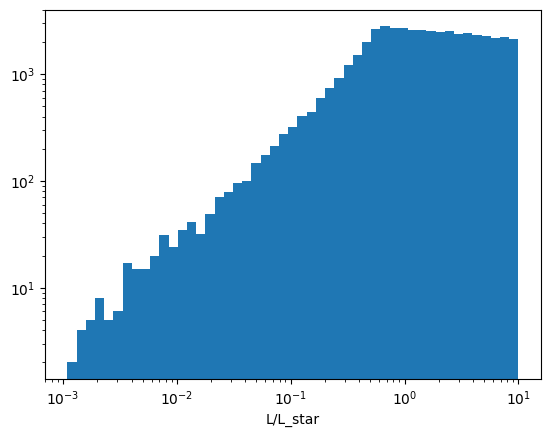

In [109]:
L = generate_schechter_lum(npix, L_star=1e10, alpha=-1.1, L_min=1e7, L_max=1e11, phi_star=1)
bins = np.logspace(np.log10(np.min(L/1e10)), np.log10(np.max(L/1e10)), 50)
get_hist(L/1e10, xlabel='L/L_star', bins=bins)
plt.yscale('log')
plt.xscale('log');

Number of rejects = 75419


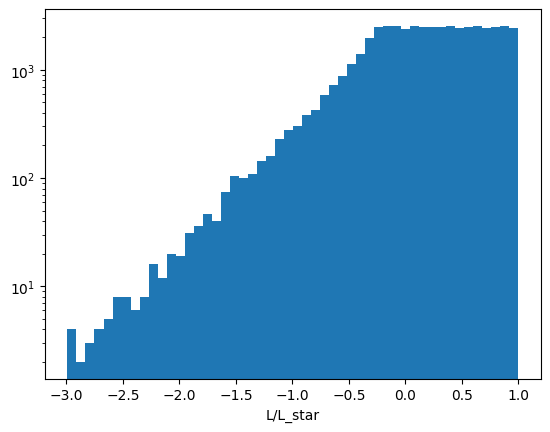

In [110]:
L = generate_schechter_lum(npix, L_star=1e10, alpha=-1.001, L_min=1e7, L_max=1e11, phi_star=1)
get_hist(np.log10(L/1e10), xlabel='L/L_star', bins=50)
plt.yscale('log')
#plt.xscale('log');

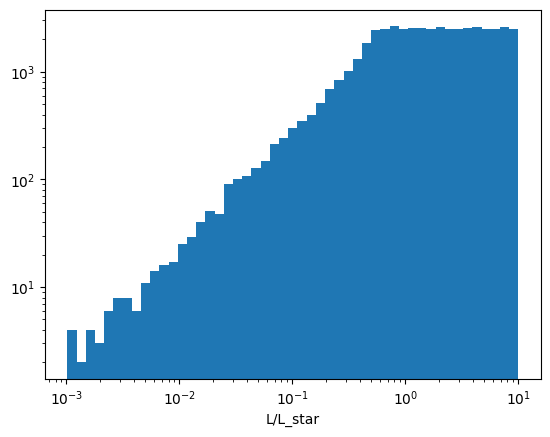

In [111]:
bins = np.logspace(np.log10(np.min(L/1e10)), np.log10(np.max(L/1e10)), 50)
get_hist(L/1e10, xlabel='L/L_star', bins=bins)
plt.yscale('log')
plt.xscale('log');

#### Schechter ratio:

Number of rejects = 123736


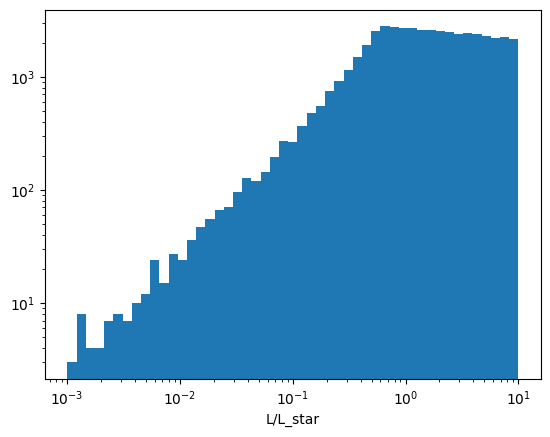

In [5]:
def proba_schechter_lumRatio(x, alpha, phi_star=1):
        return phi_star * np.power(x, alpha) * np.exp(-x)


def generate_schechter_lumRatio(n_samples, alpha, x_min, x_max, phi_star=1, get_proba=False):
    """Generate N randomized luminosities, by using a reject test and Schechter's law."""
    samples = []
    proba = []
    reject = 0 #to count the number of rejects
    
    while len(samples) < n_samples:
        L_cand = sample_truncated_power_law(alpha, x_min, x_max)
        L_test =  L_cand**alpha #g(L_cand)
        p_test = np.random.uniform(0, L_test)
        
        if p_test < L_test/proba_schechter_lumRatio(L_cand, alpha, phi_star):
            samples.append(L_cand)
            proba.append(p_test)
        else: reject += 1
    print('Number of rejects =', reject)
    if get_proba: return np.array(samples), np.array(proba)
    else: return np.array(samples)


L_ratio = generate_schechter_lumRatio(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True)
plt.xscale('log');

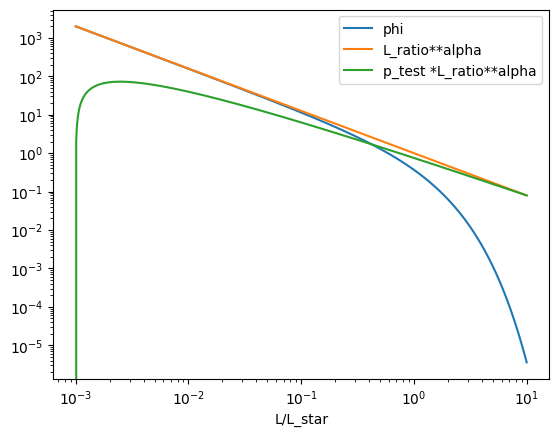

In [57]:
L_ratio = np.logspace(-3, 1, 1000)
p_test = np.linspace(0, 1, 1000)
phi_test = proba_schechter_lumRatio(L_ratio, -1.1)
pow = L_ratio**(-1.1)
plt.plot(L_ratio, phi_test, label='phi')
plt.plot(L_ratio, pow, label='L_ratio**alpha')
plt.plot(L_ratio, pow*p_test, label='p_test *L_ratio**alpha')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('L/L_star')
plt.legend();

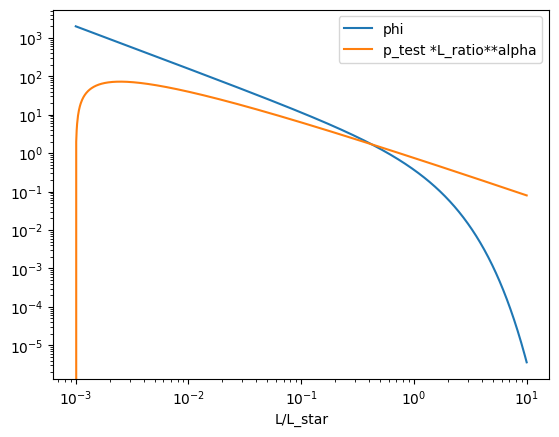

In [61]:
plt.plot(L_ratio, phi_test, label='phi')
plt.plot(L_ratio, pow*p_test, label='p_test *L_ratio**alpha')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('L/L_star')
plt.legend();

Number of rejects = 123664


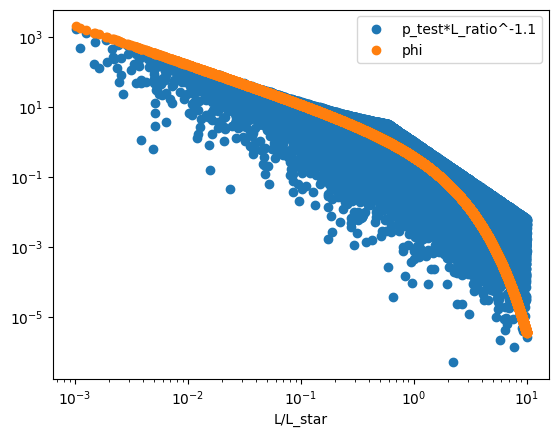

In [65]:
L_ratio, p = generate_schechter_lumRatio(npix, alpha=-1.1, x_min=1e-3, x_max=10, phi_star=1, get_proba=True)
phi = proba_schechter_lumRatio(L_ratio, -1.1)
y = p*np.power(L_ratio, -1.1)
plt.scatter(L_ratio, y, label='p_test*L_ratio^-1.1');
plt.scatter(L_ratio, phi, label='phi')
plt.xlabel('L/L_star')
plt.xscale('log')
plt.yscale('log')
plt.legend();

Number of rejects = 124466


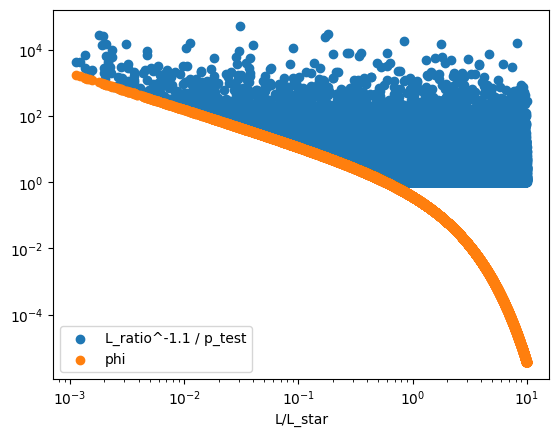

In [67]:
L_ratio, p = generate_schechter_lumRatio(npix, alpha=-1.1, x_min=1e-3, x_max=10, phi_star=1, get_proba=True)
phi = proba_schechter_lumRatio(L_ratio, -1.1)
y = np.power(L_ratio, -1.1)/p
plt.scatter(L_ratio, y, label='L_ratio^-1.1 / p_test');
plt.scatter(L_ratio, phi, label='phi')
plt.xlabel('L/L_star')
plt.xscale('log')
plt.yscale('log')
plt.legend();

/tmp/ipykernel_1541/2598318290.py:6: RuntimeWarning: divide by zero encountered in divide
  plt.plot(L_ratio, pow/p_test, label='L_ratio**alpha / p_test')


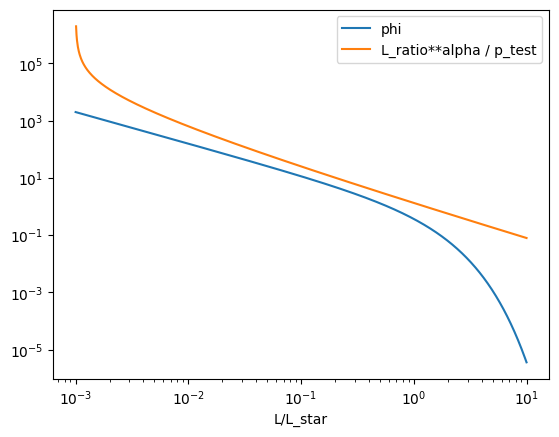

In [69]:
L_ratio = np.logspace(-3, 1, 1000)
p_test = np.linspace(0, 1, 1000)
phi_test = proba_schechter_lumRatio(L_ratio, -1.1)
pow = L_ratio**(-1.1)
plt.plot(L_ratio, phi_test, label='phi')
plt.plot(L_ratio, pow/p_test, label='L_ratio**alpha / p_test')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('L/L_star')
plt.legend();

#### Gemini's version:

Number of rejects = 14674


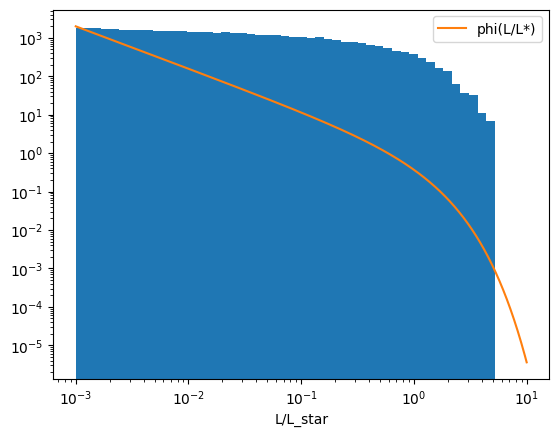

In [22]:
def generate_schechter_lumRatio_v2(n_samples, alpha, x_min, x_max, phi_star=1):
    samples = []
    reject = 0
    
    while len(samples) < n_samples:
        # 1. Tirer un candidat selon la loi de puissance g(x)
        L_cand = sample_truncated_power_law(alpha, x_min, x_max)
        
        # 2. Calculer le ratio d'acceptation
        # f(x) = x^alpha * exp(-x)
        # g(x) = x^alpha (on ignore la constante de normalisation qui s'annule)
        # f(x)/g(x) = exp(-x)
        acceptance_ratio = np.exp(-L_cand)
        
        # 3. Test d'acceptation
        u = np.random.uniform(0, 1)
        if u < acceptance_ratio:
            samples.append(L_cand)
        else:
            reject += 1
            
    print(f'Number of rejects = {reject}')
    return np.array(samples)


L_ratio = generate_schechter_lumRatio_v2(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True)
plt.xscale('log');


L_test = np.logspace(-3, 1, 1000)
phi_test = proba_schechter_lumRatio(L_test, -1.1)
plt.plot(L_test, phi_test, label = 'phi(L/L*)')
plt.legend();

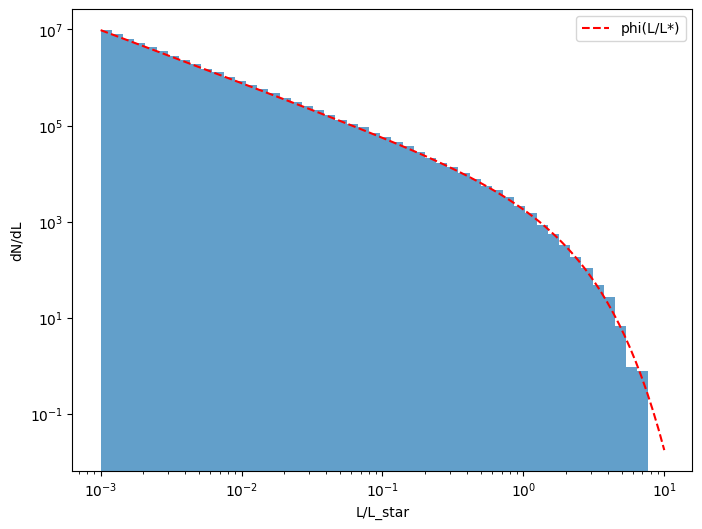

In [19]:
samples = L_ratio
x_min, x_max = 1e-3, 10
alpha = -1.1

# 1. Créer des bins logarithmiques
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)

# 2. Tracer l'histogramme normalisé
# 'density=True' normalise l'aire totale, mais pour voir la pente alpha,
# il faut diviser le contenu de chaque bin par sa largeur (width).
counts, bin_edges = np.histogram(samples, bins=bins)
bin_widths = np.diff(bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# On normalise dN/dL
density = counts / bin_widths

plt.figure(figsize=(8, 6))
plt.bar(bin_centers, density, width=bin_widths, align='center', alpha=0.7)

# Tracer la loi théorique pour comparer
x_theory = np.logspace(np.log10(x_min), np.log10(x_max), 100)
y_theory = proba_schechter_lumRatio(x_theory, alpha) 
# Note : il faudra peut-être multiplier y_theory par une constante 
# pour l'ajuster à l'échelle de tes données (normalisation).
plt.plot(x_theory, y_theory * (density[0]/y_theory[0]), 'r--', label='phi(L/L*)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('L/L_star')
plt.ylabel('dN/dL')
plt.legend()

#### z, m, M, L, dL_mpc:

Number of rejects = 124478


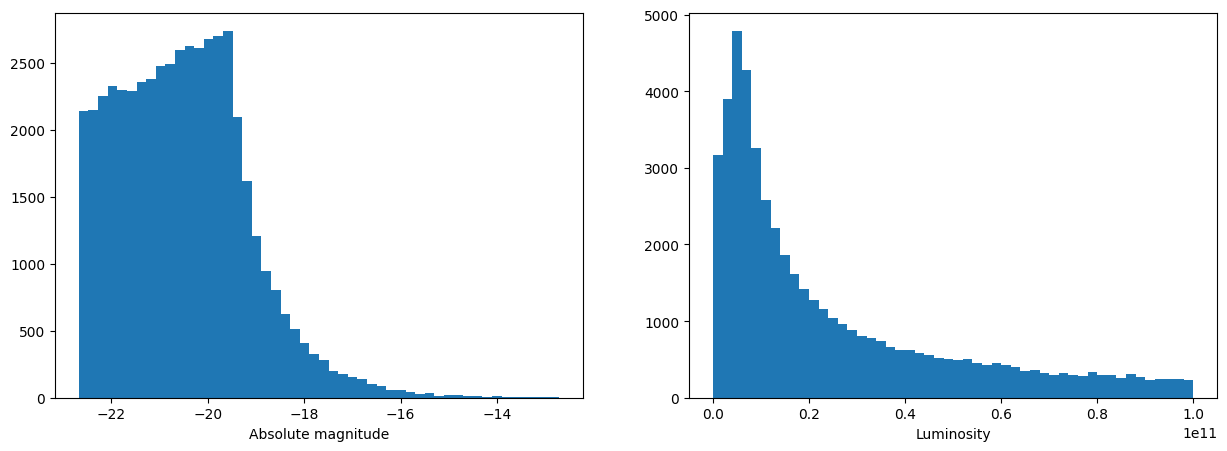

In [48]:
z, m, M, L, dL_mpc = generate_lumMag(npix)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]));

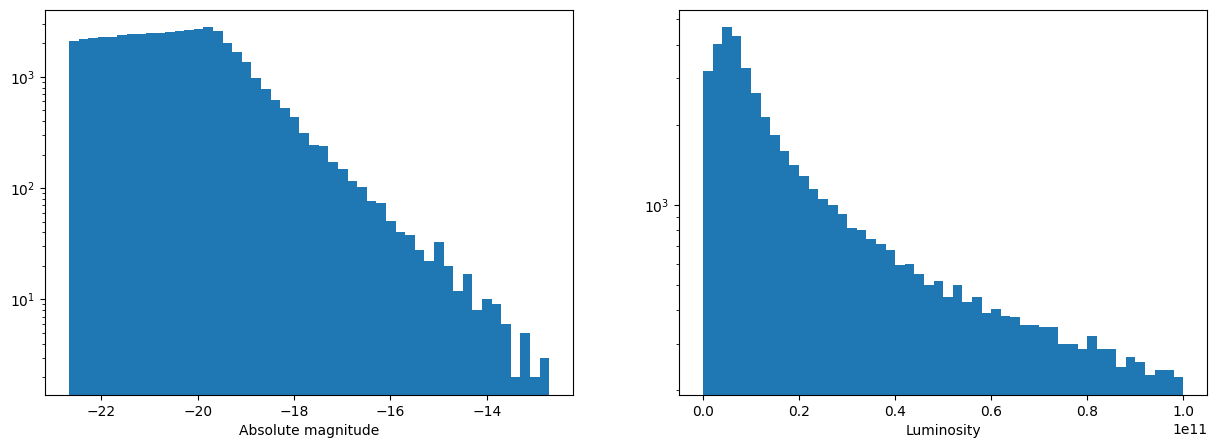

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_yscale('log');

### Log-log space:

Number of rejects = 0


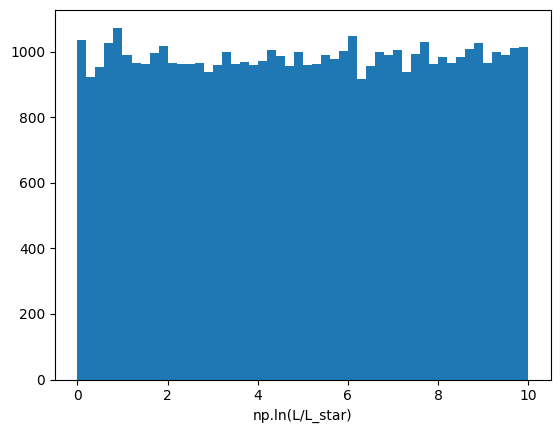

In [11]:
def proba_schechter_lumLog(x, alpha, phi_star=1):
    """x = ln(L/L*)"""
    return alpha*x - np.exp(x) + np.log(phi_star)


def proba_schechter_lumLog10(x, alpha, phi_star=1):
    """x = log10(L/L*)"""
    return alpha*x - np.log10(np.e)*10**x + np.log10(phi_star)


def sample_truncated_power_lawLog(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ (10^x)^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = xmin * exponent
    xmax_exp = xmax * exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) * (1 / exponent)

    return samples


def generate_schechter_lumLog(n_samples, alpha, x_min, x_max, phi_star=1, fproba=proba_schechter_lumLog):
    """
    Tire log(L/L*) suivant Schechter.
    x = log(L/L*)
    """
    samples = []
    reject = 0 #to count the number of rejects
    
    while len(samples) < n_samples:
        x_cand = sample_truncated_power_lawLog(alpha, x_min, x_max)
        x_test = x_cand*alpha #g(x_cand)
        p_test = np.random.uniform(0, x_test)
        
        if p_test < x_test/fproba(x_cand, alpha, phi_star):
            samples.append(x_cand)
        else: reject += 1
    print('Number of rejects =', reject) 
    return np.array(samples)


x = generate_schechter_lumLog(npix, alpha=-1.001, x_min=1e-3, x_max=10, fproba=proba_schechter_lumLog)
get_hist(x, xlabel='np.ln(L/L_star)', bins=50);
#plt.yscale('log');
#plt.xscale('log');

Number of rejects = 0


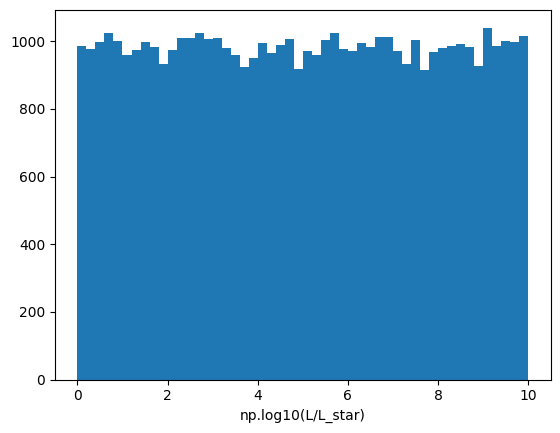

In [12]:
x = generate_schechter_lumLog(npix, alpha=-1.001, x_min=1e-3, x_max=10, fproba=proba_schechter_lumLog10)
get_hist(x, xlabel='np.log10(L/L_star)', bins=50);
# plt.yscale('log');
# plt.xscale('log');

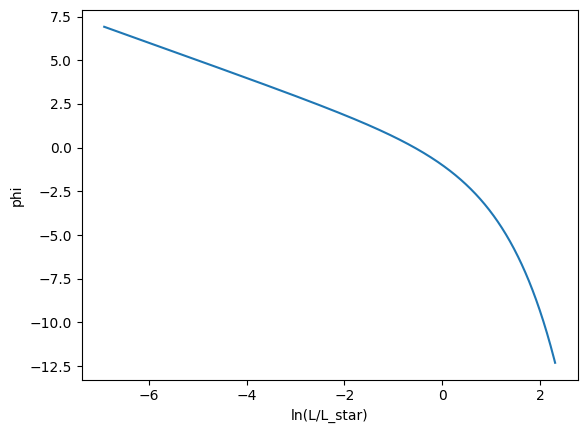

In [13]:
L_test = np.logspace(-3, 1, 1000)
L_test = np.log(L_test)
phi_test = proba_schechter_lumLog(L_test, -1.001)
plt.plot(L_test, phi_test)
plt.xlabel('ln(L/L_star)')
plt.ylabel('phi');

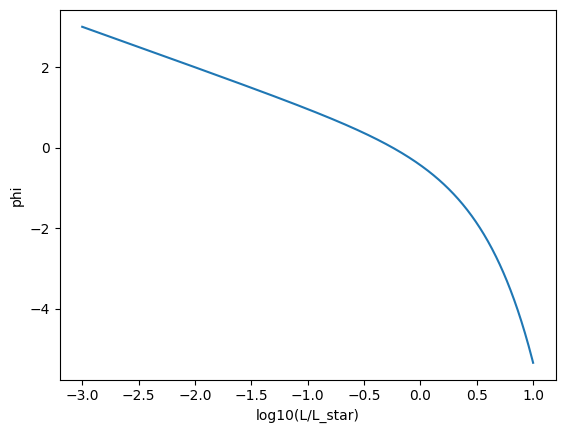

In [14]:
L_test = np.logspace(-3, 1, 1000)
L_test = np.log10(L_test)
phi_test = proba_schechter_lumLog10(L_test, -1.001)
plt.plot(L_test, phi_test)
plt.xlabel('log10(L/L_star)')
plt.ylabel('phi');

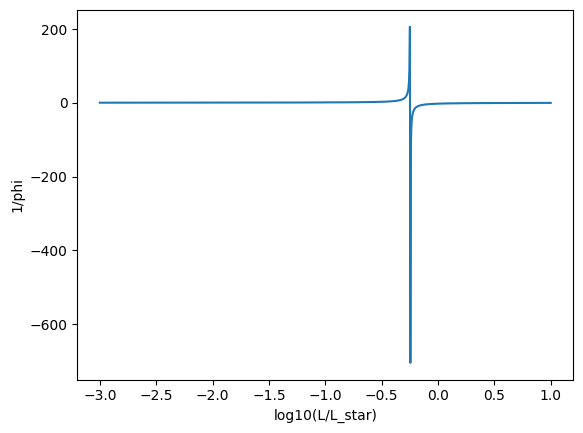

In [15]:
L_test = np.logspace(-3, 1, 1000)
L_test = np.log10(L_test)
phi_test = proba_schechter_lumLog10(L_test, -1.001)
plt.plot(L_test, 1/phi_test)
plt.xlabel('log10(L/L_star)')
plt.ylabel('1/phi');

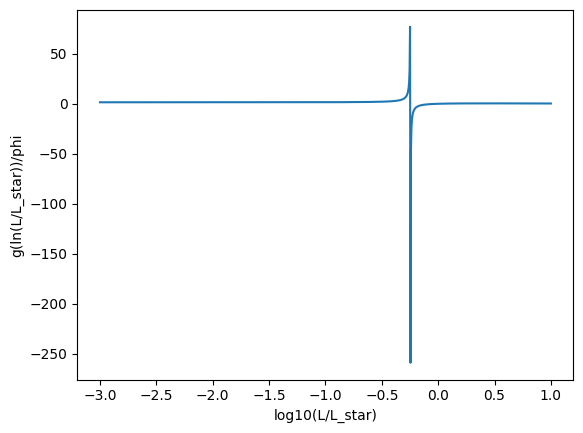

In [16]:
plt.plot(L_test, L_test*(-1.5)/phi_test)
plt.xlabel('log10(L/L_star)')
plt.ylabel('g(ln(L/L_star))/phi');